# Importing Data from the CSV File and performing analysis

In [457]:
import pandas as pd
import numpy as np
import seaborn as sns

In [458]:
df = pd.read_csv("../datasets/raw_data.csv")
df = pd.DataFrame(df)

In [459]:
df.isnull().sum()

customerID             0
gender               748
SeniorCitizen        659
Partner             3530
Dependents          3565
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

## Handling Missing Values


In [460]:
def fill_mode(df, columns):
    for col in columns:
        df[col] = df[col].fillna(df[col].mode()[0])


In [461]:
mode_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PaymentMethod'
]

fill_mode(df, mode_cols)

In [462]:
def fill_median(df, columns):

    for col in columns:
        df[col] = df[col].fillna(df[col].median())


In [463]:
median_cols = [
    'tenure',
    'MonthlyCharges'
]

fill_median(df, median_cols)

In [464]:
def fill_service_columns(df, columns, value):

    for col in columns:
        df[col] = df[col].fillna(value)


In [465]:
internet_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

fill_service_columns(df, internet_cols, 'No internet service')

In [466]:
df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')


In [467]:
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges        1062
Churn                  0
dtype: int64

- **Drop Column** → Column has no predictive value  
- **Mode Imputation** → Best for categorical/binary features  
- **Median Imputation** → Robust against outliers and skewed data  
- **"No internet service" Filling** → Missing value carries business meaning  
- **"No phone service" Filling** → Missing likely means no phone subscription  


## Handling Wrong Inputs

In [468]:
df['gender'].value_counts()

gender
Female    34858
Male      33252
Man         500
male        374
FEMALE      351
m           339
f           326
Name: count, dtype: int64

In [469]:
M = ['man', 'male', 'm']
F = ['woman', 'female', 'f']

normalized = df['gender'].astype(str).str.strip().str.lower()

df.loc[normalized.isin(M), 'gender'] = 'Male'
df.loc[normalized.isin(F), 'gender'] = 'Female'

In [470]:
df['gender'].value_counts()

gender
Female    35535
Male      34465
Name: count, dtype: int64

In [471]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0             53064
1             10388
Yes            3559
No             2739
not senior      250
Name: count, dtype: int64

In [472]:
Yes = ['1', 'yes']
NO = ['0', 'no', 'not senior']

normalized = (
    df['SeniorCitizen']
    .astype(str)
    .str.strip()
    .str.lower()
)

df.loc[normalized.isin(Yes), 'SeniorCitizen'] = 'Yes'
df.loc[normalized.isin(NO), 'SeniorCitizen'] = 'No'

In [473]:
df['tenure'].unique()

array([  3.,   2.,  42.,  40.,  17.,  18.,  25.,  33.,   6.,  -5.,  22.,
        10.,   8.,   5.,  47.,  28.,  44.,  12., -10.,  38.,  21.,   4.,
        16.,  29.,  51.,  15.,   9.,  23.,  43.,  34.,  31.,  19.,  45.,
       999.,   7.,  65.,  14.,  20.,  13.,  32.,  26.,  71.,  36.,  11.,
        41.,  24.,  50.,  39.,  30.,  48.,  46.,  27.,  52.,   1.,  37.,
        61.,  54.,  35.,  70.,  56.,  69.,  72.,  63.,  53.,  68.,  57.,
        58.,  62.,  66.,  67.,  60.,  49.,  55.,  64.,  59.])

In [474]:
df.loc[(df['tenure'] < 0) | (df['tenure'] > 72), 'tenure'] = df['tenure'].median()

In [475]:
df['OnlineSecurity'].unique()

<StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str

In [476]:
Yes = ['Y', 'True']
normalized = df['OnlineSecurity'].astype(str).str.strip()

df.loc[normalized.isin(Yes), 'OnlineSecurity'] = 'Yes'


In [477]:
df['OnlineSecurity'].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [478]:
df['OnlineBackup'].unique()

<StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str

In [479]:
Yes = ['Y', 'True']
normalized = df['OnlineBackup'].astype(str).str.strip()

df.loc[normalized.isin(Yes), 'OnlineBackup'] = 'Yes'


In [480]:
df['OnlineBackup'].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [481]:
df['DeviceProtection'].unique()

<StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str

In [482]:
Yes = ['Y', 'True']
normalized = df['DeviceProtection'].astype(str).str.strip()

df.loc[normalized.isin(Yes), 'DeviceProtection'] = 'Yes'

In [483]:
df['DeviceProtection'].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [484]:
df['TechSupport'].unique()

<StringArray>
['No internet service', 'Yes', 'No', 'Y', 'True']
Length: 5, dtype: str

In [485]:
Yes = ['Y', 'True']
normalized = df['TechSupport'].astype(str).str.strip()

df.loc[normalized.isin(Yes), 'TechSupport'] = 'Yes'

In [486]:
df['TechSupport'].unique()

<StringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str

In [487]:
df['StreamingTV'].unique()

<StringArray>
['No internet service', 'Yes', 'No', 'Y', 'True']
Length: 5, dtype: str

In [488]:
Yes = ['Y', 'True']
normalized = df['StreamingTV'].astype(str).str.strip()

df.loc[normalized.isin(Yes), 'StreamingTV'] = 'Yes'

In [489]:
df['StreamingTV'].unique()

<StringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str

In [490]:
df['StreamingMovies'].unique()

<StringArray>
['No internet service', 'No', 'Yes', 'Y', 'True']
Length: 5, dtype: str

In [491]:
Yes = ['Y', 'True']
normalized = df['StreamingMovies'].astype(str).str.strip()

df.loc[normalized.isin(Yes), 'StreamingMovies'] = 'Yes'

In [492]:
df['StreamingMovies'].unique()

<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

In [493]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year', 'M-M']
Length: 4, dtype: str

In [494]:
df.loc[df['Contract'] == 'M-M', 'Contract'] = 'Month-to-month'

In [495]:
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [496]:
df['PaperlessBilling'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [497]:
df['PaperlessBilling'].isnull().sum()

np.int64(0)

In [498]:
df['PaymentMethod'].unique(
    
)

<StringArray>
[             'Mailed check', 'Bank transfer (automatic)',
          'Electronic check',   'Credit card (automatic)',
             'BANK TRANSFER']
Length: 5, dtype: str

In [499]:
df.loc[df['PaymentMethod'] == 'Bank transfer (automatic)', 'PaymentMethod'] = 'Bank transfer'
df.loc[df['PaymentMethod'] == 'Credit card (automatic)', 'PaymentMethod'] = 'Credit card'
df.loc[df['PaymentMethod'] == 'BANK TRANSFER', 'PaymentMethod'] = 'Bank transfer'

In [500]:
df['PaymentMethod'].unique()

<StringArray>
['Mailed check', 'Bank transfer', 'Electronic check', 'Credit card']
Length: 4, dtype: str

In [501]:
df['MonthlyCharges'].isnull().sum()

np.int64(0)

In [502]:
def fill_monthlycharges_by_contract(df):


    df['MonthlyCharges'] = (
        df.groupby('Contract')['MonthlyCharges']
        .transform(lambda x: x.fillna(x.median()))
    )
fill_monthlycharges_by_contract(df)

In [503]:
def fill_totalcharges(df):

    df['TotalCharges'] = pd.to_numeric(
        df['TotalCharges'],
        errors='coerce'
    )

    mask = df['TotalCharges'].isnull()


    df.loc[mask, 'TotalCharges'] = (
        df.loc[mask, 'MonthlyCharges'] *
        df.loc[mask, 'tenure']
    )

In [504]:
fill_totalcharges(df)

In [505]:
df['Churn'].unique()

<StringArray>
['Yes', 'No', 'Y', 'NO CHURN', 'Unknown', 'N', 'CHURNED']
Length: 7, dtype: str

In [506]:
Yes = ['YES', 'Y', 'CHURNED']
No = ['NO', 'N', 'NO CHURN']

normalized = (
    df['Churn']
    .astype(str)
    .str.strip()
    .str.upper()
)

df.loc[normalized.isin(Yes), 'Churn'] = 'Yes'
df.loc[normalized.isin(No), 'Churn'] = 'No'

In [507]:
df['Churn'].value_counts()

Churn
No         37148
Yes        32798
Unknown       54
Name: count, dtype: int64

In [508]:
df = df[df['Churn'] != 'Unknown']

In [509]:
df['Churn'].value_counts()

Churn
No     37148
Yes    32798
Name: count, dtype: int64

In [510]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [511]:
df['Churn'].value_counts()

Churn
0    37148
1    32798
Name: count, dtype: int64

In [512]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='Churn', ylabel='count'>

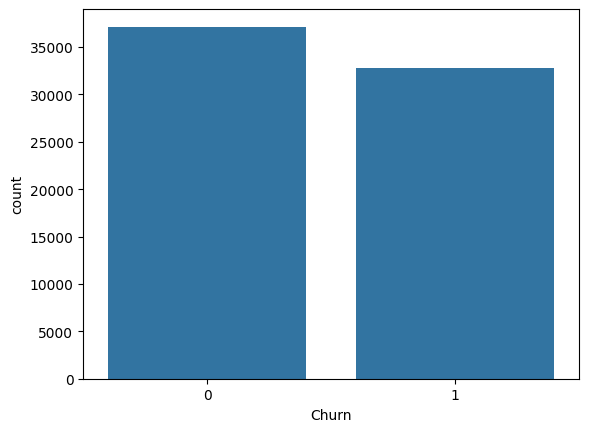

In [513]:
sns.countplot(x='Churn', data=df)

<Axes: xlabel='Contract', ylabel='count'>

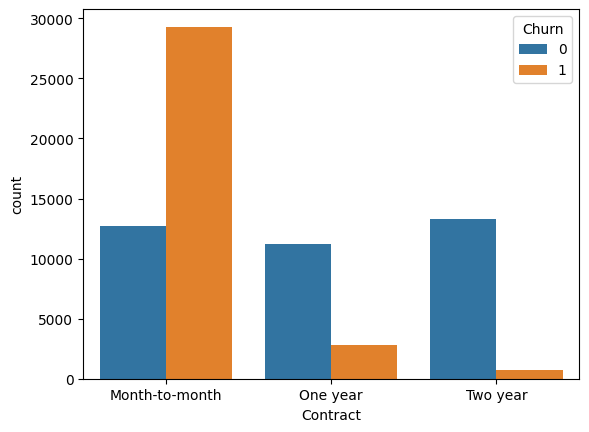

In [514]:
sns.countplot(x='Contract', hue='Churn', data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

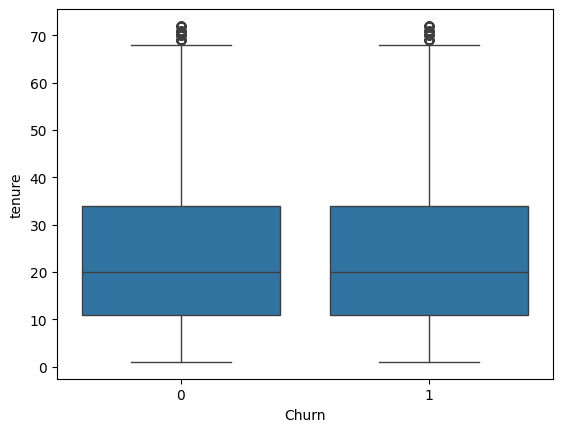

In [515]:
sns.boxplot(x='Churn', y='tenure', data=df)

In [516]:
df.to_csv('../datasets/cleaned_data.csv', index=False)